# Test file for DDPG agents and further analyses

Import the required libraries

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.autograd import Variable
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm  # Import tqdm for progress bar

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Load data

In [ ]:
# Load and normalize data
df = pd.read_excel("hourly_data.xlsx") 
df1 = pd.read_excel("commercial_data.xlsx")
df1['Commercial_load'] = df1['Commercial_load'] + 250000 # Offset to match loads

View the data

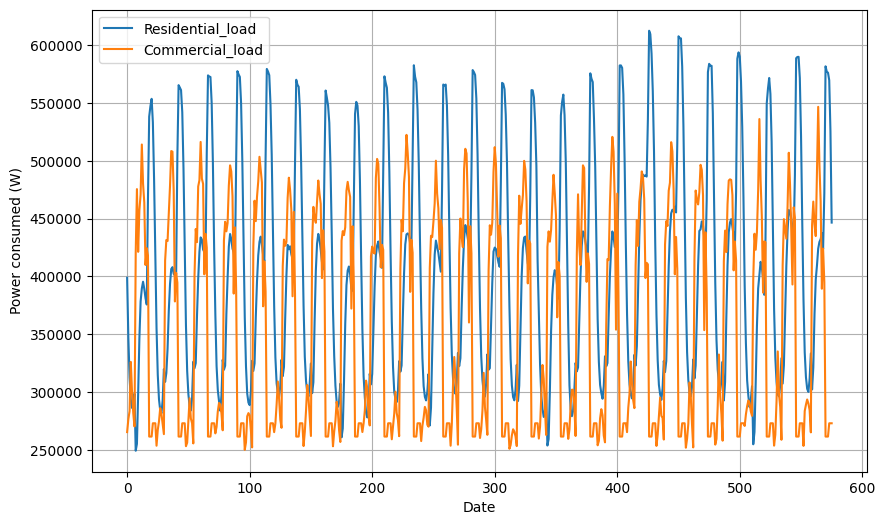

In [78]:
loads_df = pd.DataFrame({
    'Residential_load':df['Total Power Consumption'][:192*3].values,
    'Commercial_load':df1['Commercial_load'][:192*3].values
})

plt.figure(figsize=(10, 6))
plt.plot(loads_df['Residential_load'], label='Residential_load')
plt.plot(loads_df['Commercial_load'], label='Commercial_load')

# Customize the plot
plt.xlabel("Date")
plt.ylabel("Power consumed (W)")
plt.legend()
plt.grid(True)
plt.show()


Min-max normalization

In [79]:
# Normalize data
scaler = MinMaxScaler()
res_max = 700000
com_max = 600000
res_load_data = (loads_df['Residential_load'].values).reshape(-1, 1)
res_norm_load = scaler.fit_transform(res_load_data)

com_load_data = (loads_df['Commercial_load'].values).reshape(-1, 1)
com_norm_load = scaler.fit_transform(com_load_data)

util_res_load_data = (loads_df['Residential_load'].values/res_max).reshape(-1, 1)
util_res_norm_load = scaler.fit_transform(util_res_load_data)

util_com_load_data = (loads_df['Commercial_load'].values/com_max).reshape(-1, 1)
util_com_norm_load = scaler.fit_transform(util_com_load_data)


### Agents classes' definitions

In [80]:
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)
        self.tanh = nn.Tanh()
    
    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        x = self.tanh(self.fc3(x))  # Output between -1 and 1
        return (x + 1) / 2  # Scale to range 0 to 1

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_dim + action_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)
    
    def forward(self, state, action):
        x = torch.cat([state, action], dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


In [81]:
class DDPGAgent:
    def __init__(self, state_dim, action_dim, lr_actor=0.001, lr_critic=0.002, gamma=0.99, tau=0.005):
        self.actor = Actor(state_dim, action_dim).to(dev)
        self.critic = Critic(state_dim, action_dim).to(dev)
        self.target_actor = Actor(state_dim, action_dim).to(dev)
        self.target_critic = Critic(state_dim, action_dim).to(dev)
        
        self.target_actor.load_state_dict(self.actor.state_dict())
        self.target_critic.load_state_dict(self.critic.state_dict())
        
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic)
        self.gamma = gamma
        self.tau = tau
    
    def select_action(self, state):
        state = torch.FloatTensor(state).to(dev).unsqueeze(0)
        action = self.actor(state).cpu().detach().numpy()
        return action[0]
    
    def update(self, replay_buffer, batch_size=64):
        if len(replay_buffer) < batch_size:
            return
        
        batch = [replay_buffer[i] for i in np.random.choice(len(replay_buffer), batch_size, replace=False)]
        states, actions, rewards, next_states = zip(*batch)
        
        states = torch.FloatTensor(states).to(dev)
        actions = torch.FloatTensor(actions).to(dev)
        rewards = torch.FloatTensor(rewards).to(dev).unsqueeze(1)
        next_states = torch.FloatTensor(next_states).to(dev)
        
        next_actions = self.target_actor(next_states)
        target_q = rewards + self.gamma * self.target_critic(next_states, next_actions).detach()
        
        q_values = self.critic(states, actions)
        critic_loss = F.mse_loss(q_values, target_q)
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        
        actor_loss = -self.critic(states, self.actor(states)).mean()
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        
        for param, target_param in zip(self.actor.parameters(), self.target_actor.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
        
        for param, target_param in zip(self.critic.parameters(), self.target_critic.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)


Save and load the agent functions

In [82]:
def save_ddpg(agent, filename):
    torch.save({
        'actor_state_dict': agent.actor.state_dict(),
        'critic_state_dict': agent.critic.state_dict(),
        'actor_optimizer_state_dict': agent.actor_optimizer.state_dict(),
        'critic_optimizer_state_dict': agent.critic_optimizer.state_dict()
    }, filename)
    print(f"DDPG agent saved to {filename}")

def load_ddpg(agent, filename):
    checkpoint = torch.load(filename)
    agent.actor.load_state_dict(checkpoint['actor_state_dict'])
    agent.critic.load_state_dict(checkpoint['critic_state_dict'])
    agent.actor_optimizer.load_state_dict(checkpoint['actor_optimizer_state_dict'])
    agent.critic_optimizer.load_state_dict(checkpoint['critic_optimizer_state_dict'])
    print(f"DDPG agent loaded from {filename}")

### EV load data generation functions

In [83]:
# Generate random numbers based on Gaussian distribution function
def generate_random_numbers(mu, sigma, num_points):
    # Set the seed for reproducibility
    np.random.seed()
    incrementor = 0     # net for control
    # generate only positive numbers
    while True :
        random_numbers = np.random.normal(mu, sigma, num_points)
        if all(num >= 0 for num in random_numbers):
            break
        elif incrementor == 100000:
            random_numbers = np.zeros(num_points)
            break
        incrementor += 1
    # print(incrementor)
    return random_numbers

# Sort the numbers to be bell-shaped
def sort_array_gaussian(arr):
    # Sort the array in descending order
    sorted_arr = sorted(arr, reverse=True)
    
    length_ = len(arr)
    # Create a new array to store the sorted elements
    result = np.zeros(length_, dtype=int)
    
    # Flag to keep track of whether to insert from the beginning or the end
    insert_from_beginning = True
    
    for i in range(length_):
        # If the flag is True, insert the smallest element from the sorted array
        if insert_from_beginning:
            result[i] = sorted_arr[i]
        # If the flag is False, insert the largest element from the sorted array
        else:
            result[length_-1-i] = sorted_arr[i]
        
        # Toggle the flag to alternate between inserting from the beginning and the end
        insert_from_beginning = not insert_from_beginning
    
    return result

def residential_charging(mu, sigma):
    component_1,component_2,component_3,component_4,component_5,component_6 = np.zeros(24, dtype = float),np.zeros(24, dtype = float),np.zeros(24, dtype = float),np.zeros(24, dtype = float),np.zeros(24, dtype = float),np.zeros(24, dtype = float)
    
    component_1[0:7] += sort_array_gaussian(generate_random_numbers(mu, sigma, 7))
    component_2[7:10] += sort_array_gaussian(generate_random_numbers(0.1*mu, sigma, 3))
    component_3[10:15] += sort_array_gaussian(generate_random_numbers(0.05*mu, sigma, 5))
    component_4[15:18] += sort_array_gaussian(generate_random_numbers(0.15*mu, sigma, 3))
    component_5[18:21] += sort_array_gaussian(generate_random_numbers(0.3*mu, 0, 3))
    component_6[21:24] += sort_array_gaussian(generate_random_numbers(0.5*mu, 1, 3))
    
    combined_components = component_1 + component_2 + component_3 + component_4 + component_5 + component_6
    return combined_components

def commercial_charging(mu, sigma):
    component_1,component_2,component_3,component_4,component_5,component_6 = np.zeros(24, dtype = float),np.zeros(24, dtype = float),np.zeros(24, dtype = float),np.zeros(24, dtype = float),np.zeros(24, dtype = float),np.zeros(24, dtype = float)
    
    component_1[0:7] += sort_array_gaussian(generate_random_numbers(0.05*mu, sigma, 7))
    component_2[7:10] += sort_array_gaussian(generate_random_numbers(0.3*mu, sigma, 3))
    component_3[10:15] += sort_array_gaussian(generate_random_numbers(0.9*mu, sigma, 5))
    component_4[15:18] += sort_array_gaussian(generate_random_numbers(0.7*mu, sigma, 3))
    component_5[18:21] += sort_array_gaussian(generate_random_numbers(0.3*mu, 0, 3))
    component_6[21:24] += sort_array_gaussian(generate_random_numbers(0.1*mu, 1, 3))
    
    combined_components = component_1 + component_2 + component_3 + component_4 + component_5 + component_6
    return combined_components

def pv_optimal_ev_load(load,mu):
    return (mu*(1-scaler.fit_transform(load))).flatten() + (generate_random_numbers(0.2*mu, 0.1*mu, 24))

def pvb_optimal_ev_load(load,mu,util_diff):
    return (0.5*mu*((1-scaler.fit_transform(load))+(1-scaler.fit_transform(util_diff)))).flatten() + (generate_random_numbers(0.1*mu, 0.01*mu, 24))

Testing the functions

In [84]:
res_max = 1166666
com_max = 1000000
time_labels = ['00:00',' ',' ',' ',' ',' ',' ',' ',' ',' ',' ',' ','12:00',' ',' ',' ',' ',' ',' ',' ',' ',' ',' ','23:00']
conv_prices = np.array([0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, # 12AM to 6AM
                          0.4, 0.7, 0.7, # 7AM to 9AM
                          0.7, 1, 1, 1, 1, 1, 0.7, 0.7, #10AM to 5PM
                          0.7, 1, 1, 1, 0.7, 0.7])  #6PM to 11PM

ev_com_load_unbalanced = commercial_charging(350000,17000)
ev_res_load_unbalanced = residential_charging(350000,17000)


state_dim = 24  # 24-hour load states
action_dim = 24  # 24 actions per time step
agent = DDPGAgent(state_dim=state_dim, action_dim=action_dim)
agent_com_p2 = DDPGAgent(state_dim=state_dim, action_dim=action_dim)
agent_res_p2 = DDPGAgent(state_dim=state_dim, action_dim=action_dim)

# Load data and extract the required columns
test_com_df = pd.read_excel("commercial_data.xlsx")
test_com_df = test_com_df[(192*3):(192*3)+24]
test_com_df['Commercial_load']= test_com_df['Commercial_load'] + 250000
test_com_load_data = test_com_df['Commercial_load'].values.reshape(-1, 1)

test_res_df = pd.read_excel("hourly_data.xlsx")
test_res_df = test_res_df[(192*3):(192*3)+24]
test_res_load_data = test_res_df['Total Power Consumption'].values.reshape(-1, 1)

# Prepare data for agents
util_res_load_data = (test_res_df['Total Power Consumption'].values/res_max).reshape(-1, 1)
util_res_norm_load = scaler.fit_transform(util_res_load_data)

util_com_load_data = (test_com_df['Commercial_load'].values/com_max).reshape(-1, 1)
util_com_norm_load = scaler.fit_transform(util_com_load_data)

res_utils_diff = np.array(util_res_load_data - util_com_load_data)
com_utils_diff = np.array(util_com_load_data - util_res_load_data)

test_com_norm_load = scaler.fit_transform(test_com_load_data)
test_com_state = test_com_norm_load.flatten()

test_res_norm_load = scaler.fit_transform(test_res_load_data)
test_res_state = test_res_norm_load.flatten()

load_ddpg(agent, filename='ddpg_agent_5000.pth')
test_com_action_p1 = agent.select_action(test_com_state)  # 24 separate actions
test_res_action_p1 = agent.select_action(test_res_state)  # 24 separate actions

load_ddpg(agent_com_p2, filename='ddpg_agent_a2_com.pth')
test_com_action_p2 = agent_com_p2.select_action(test_com_state)  # 24 separate actions

load_ddpg(agent_res_p2, filename='ddpg_agent_a2_res.pth')
test_res_action_p2 = agent_res_p2.select_action(test_res_state)  # 24 separate actions

com_pv_ev_load = pv_optimal_ev_load(test_com_df['Commercial_load'].values.reshape(-1, 1), 0.5*max(ev_com_load_unbalanced))
com_pvb_ev_load = pvb_optimal_ev_load(test_com_df['Commercial_load'].values.reshape(-1, 1), 0.5*max(ev_com_load_unbalanced), com_utils_diff)

res_pv_ev_load = pv_optimal_ev_load(test_res_df['Total Power Consumption'].values.reshape(-1, 1), 0.5*max(ev_res_load_unbalanced))
res_pvb_ev_load = pvb_optimal_ev_load(test_res_df['Total Power Consumption'].values.reshape(-1, 1), 0.5*max(ev_res_load_unbalanced), res_utils_diff)

# Combine the columns into the new dataframe and the other attributes
combined_df = pd.DataFrame({
    'Time': test_com_df['Time'],
    'Commercial_load': test_com_df['Commercial_load'],
    'Residential_load': test_res_df['Total Power Consumption'],
    'Res_utils_data': util_res_load_data.ravel(),
    'Com_utils_data': util_com_load_data.ravel(),
    'Res_utils_diff': res_utils_diff.ravel(),
    'Com_utils_diff': com_utils_diff.ravel(),
    'Res_action_p1': test_res_action_p1.ravel(),
    'Com_action_p1': test_com_action_p1.ravel(),
    'Res_action_p2': test_res_action_p2.ravel(),
    'Com_action_p2': test_com_action_p2.ravel(),
    'Com_pv_ev_load': com_pv_ev_load.ravel(),
    'Com_pvb_ev_load': com_pvb_ev_load.ravel(),
    'Res_pv_ev_load': res_pv_ev_load.ravel(),
    'Res_pvb_ev_load': res_pvb_ev_load.ravel(),
    'Conv_prices': conv_prices
})

combined_df['EV_Com_price'] = combined_df['Conv_prices'] + 0.5*combined_df['Com_action_p1'] + 0.5*combined_df['Com_action_p2']
combined_df['EV_Res_price'] = combined_df['Conv_prices'] + 0.5*combined_df['Res_action_p1'] + 0.5*combined_df['Res_action_p2']

DDPG agent loaded from ddpg_agent_5000.pth
DDPG agent loaded from ddpg_agent_a2_com.pth
DDPG agent loaded from ddpg_agent_a2_res.pth


In [85]:
combined_df.head()

,Time,Commercial_load,Residential_load,Res_utils_data,Com_utils_data,Res_utils_diff,Com_utils_diff,Res_action_p1,Com_action_p1,Res_action_p2,Com_action_p2,Com_pv_ev_load,Com_pvb_ev_load,Res_pv_ev_load,Res_pvb_ev_load,Conv_prices,EV_Com_price,EV_Res_price
576,00:00,252816.616585,380248.30520,0.325927,0.252817,0.073111,-0.073111,0.091549,0.188438,0.0,0.000000e+00,190079.656484,144024.213039,157573.484380,123538.210823,0.4,0.494219,0.445774
577,01:00,264611.399269,335271.42742,0.287376,0.264611,0.022764,-0.022764,0.000000,0.000000,0.0,0.000000e+00,192518.248602,130333.385836,205863.532385,147560.815509,0.4,0.400000,0.400000
578,02:00,293567.576504,310739.39714,0.266348,0.293568,-0.027219,0.027219,0.000000,0.047360,0.0,0.000000e+00,162078.136451,109371.736359,227754.833397,163473.865654,0.4,0.423680,0.400000
579,03:00,302995.496876,303960.83790,0.260538,0.302995,-0.042457,0.042457,0.000000,0.142901,0.0,0.000000e+00,148245.226980,104570.587943,216027.801722,172802.444496,0.4,0.471451,0.400000
580,04:00,296059.953490,301329.94548,0.258283,0.296060,-0.037777,0.037777,0.000000,0.264066,0.0,4.470348e-07,161903.915686,108951.830628,211923.344188,169879.828533,0.4,0.532033,0.400000


### Displays

Helper functions

In [99]:
def total_load_and_prices(time, conv_load, ev_load, prices):
    # Create the figure and primary axis
    fig, ax1 = plt.subplots()

    # Conventional load: solid purple + light shading
    conv_load_line, = ax1.plot(time, conv_load, linestyle='-.', color='purple', linewidth=3, label='Conventional load')
    ax1.fill_between(time, conv_load, color='purple', alpha=0.2, hatch='//')  # diagonal shading

    # EV load: dashed blue + cross hatch
    ev_load_line, = ax1.plot(time, ev_load, linestyle='--', color='blue', linewidth=3, label='EV load')
    ax1.fill_between(time, ev_load, color='blue', alpha=0.2, hatch='xx')

    # Total load: dash-dot black + dots shading
    total_load_line, = ax1.plot(time, ev_load + conv_load, linestyle='-', color='black', linewidth=3, label='Total load')
    ax1.fill_between(time, ev_load + conv_load, color='grey', alpha=0.15, hatch='..')

    ax1.set_xlabel("Time (hours)", fontsize=20)
    ax1.set_ylabel("Load (MW)", fontsize=20)
    ax1.tick_params(axis='y')

    # Create a second y-axis
    ax2 = ax1.twinx()

    # Prices: dotted red, no shading
    prices_line, = ax2.plot(time, prices, linestyle=':', color='red', linewidth=3, label='EV charging price')
    ax2.set_ylabel(r"EV charging price", fontsize=20)
    ax2.tick_params(axis='y')

    # Rotate x-axis labels
    ax1.set_xticks(time)
    ax1.set_xticklabels(labels=time_labels, fontsize=15)

    # Legend combining both axes
    lines = [conv_load_line, ev_load_line, total_load_line, prices_line]
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, fontsize=12, loc="upper left")

    fig.tight_layout()
    plt.show()

def penetration_levels(time, conv_load, ev_load):
    _50_penetration = ev_load + conv_load
    _30_penetration = 0.6*ev_load + conv_load
    _10_penetration = 0.2*ev_load + conv_load
    plt.plot(time, _50_penetration, linestyle='-', color='red', linewidth=3, label='50% EVs penetration')
    plt.plot(time, _30_penetration, linestyle='-', color='purple', linewidth=3, label='30% EVs penetration')
    plt.plot(time, _10_penetration, linestyle='-', color='blue', linewidth=3, label='10% EVs penetration')

    plt.xticks(ticks=range(len(combined_df['Time'])), labels=time_labels, fontsize=15)
    plt.legend(fontsize = 12)
    plt.xlabel("Time (hours)", fontsize = 20)
    plt.ylabel("Load (MW)", fontsize = 20)
    plt.show()

def diff_peak_valley(tou_load, pv_load, pvb_load):
    tou_diff = max(tou_load) - min(tou_load)
    pv_diff = max(pv_load) - min(pv_load)
    pvb_diff = max(pvb_load) - min(pvb_load)

    # Bar chart data
    labels = ['10%', '20%', '30%']
    differences = [tou_diff/1000, pv_diff/1000, pvb_diff/1000]
    colors = ['red', 'purple', 'blue']

    # Plotting
    # plt.figure(figsize=(6, 5))
    plt.bar(labels, differences, color=colors)
    plt.ylabel('Peak-valley difference (kW)', fontsize=20)
    plt.xlabel('EVs penetration', fontsize=20)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(fontsize=15)
    plt.tight_layout()
    plt.show()

def kde_comparisons(tou_load, pv_load, pvb_load):
    tou_load = tou_load/1000
    pv_load = pv_load/1000
    pvb_load = pvb_load/1000
    # Bar chart data
    labels = ['10%', '20%', '30%']
    colors = ['red', 'purple', 'blue']

    sns.kdeplot(tou_load, color='red', linewidth=2, label='10%')
    tou_mean = np.mean(tou_load)
    tou_std = np.std(tou_load)
    plt.axvline(tou_mean, color='black', linestyle='--', label='10% mean')
    plt.axvline(tou_mean - tou_std, color='black', linestyle=':', label='10% ±1σ')
    plt.axvline(tou_mean + tou_std, color='black', linestyle=':')

    sns.kdeplot(pv_load, color='red', linewidth=2, label='20%')
    pv_mean = np.mean(pv_load)
    pv_std = np.std(pv_load)
    plt.axvline(pv_mean, color='black', linestyle='--', label='20% mean')
    plt.axvline(pv_mean - pv_std, color='black', linestyle=':', label='20% ±1σ')
    plt.axvline(pv_mean + pv_std, color='black', linestyle=':')

    sns.kdeplot(pvb_load, color='red', linewidth=2, label='30%')
    pvb_mean = np.mean(pvb_load)
    pvb_std = np.std(pvb_load)
    plt.axvline(pvb_mean, color='black', linestyle='--', label='30% mean')
    plt.axvline(pvb_mean - pvb_std, color='black', linestyle=':', label='30% ±1σ')
    plt.axvline(pvb_mean + pvb_std, color='black', linestyle=':')

    # Labels and formatting
    # plt.title("Comparison of Two KDE Curves with Mean and ±1 Std Dev")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plotting
    # plt.figure(figsize=(6, 5))
    # plt.bar(labels, differences, color=colors)
    # plt.ylabel('Peak-valley difference (kW)', fontsize=20)
    # plt.xlabel('EVs penetration', fontsize=20)
    # plt.grid(axis='y', linestyle='--', alpha=0.7)
    # plt.xticks(fontsize=15)
    # plt.tight_layout()
    # plt.show()

def diff_utils(res_pv_load, com_pv_load, res_pvb_load, com_pvb_load, res_max_capacity, com_max_capacity):

    # res_tou_util = (res_tou_load.values/res_max_capacity).reshape(-1, 1)
    # com_tou_util = (com_tou_load.values/com_max_capacity).reshape(-1, 1)
    res_pv_util = (res_pv_load.values/res_max_capacity).reshape(-1, 1)
    com_pv_util = (com_pv_load.values/com_max_capacity).reshape(-1, 1)
    res_pvb_util = (res_pvb_load.values/res_max_capacity).reshape(-1, 1)
    com_pvb_util = (com_pvb_load.values/com_max_capacity).reshape(-1, 1)
    
    # tou_diff = abs(np.mean(res_tou_util) - np.mean(com_tou_util))
    pv_diff = abs(np.mean(res_pv_util) - np.mean(com_pv_util))
    pvb_diff = abs(np.mean(res_pvb_util) - np.mean(com_pvb_util))

    # Bar chart data
    labels = ['PV pricing', 'PVB pricing']
    differences = [pv_diff, pvb_diff]
    colors = ['purple', 'blue']

    # Plotting
    # plt.figure(figsize=(6, 5))
    plt.bar(labels, differences, color=colors)
    plt.ylabel('Networks\' utilization difference', fontsize=15)
    plt.xticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def peak_valley(time, forecast_load, conv_prices, delta_prices):
    # Create the figure and primary axis
    fig, ax1 = plt.subplots()

    # Plot the first curve (left y-axis)
    load_line, = ax1.plot(time, forecast_load, linestyle='-', color='black', linewidth=3, label='Forecast load')
    # ax1.fill_between(time, forecast_load, color='purple', alpha=0.3)

    ax1.set_xlabel("Time (hours)", fontsize = 20)
    ax1.set_ylabel("Load (MW)", fontsize = 20)
    ax1.tick_params(axis='y')

    # Create a second y-axis
    ax2 = ax1.twinx()

    # Plot the second curve (right y-axis)
    conv_prices_line, = ax2.plot(time, conv_prices, linestyle='--', color='red', linewidth=3, label="Conventional price")
    delta_prices_line, = ax2.plot(time, delta_prices, linestyle=':', color='gold', linewidth=3, label=r"$\Delta p_a$")
    ax2.set_ylabel(r"Electricity price", fontsize = 20)
    ax2.tick_params(axis='y')

    # Rotate x-axis labels
    ax1.set_xticks(combined_df['Time'])  # Ensure all ticks are set
    ax1.set_xticklabels(labels=time_labels, fontsize=15)  # Rotate labels

    lines = [load_line, conv_prices_line, delta_prices_line]
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, fontsize = 12)
    fig.tight_layout()
    plt.show()

def peak_valley_balance(time, forecast_load, conv_prices, delta1_prices, delta2_prices):
    # Create the figure and primary axis
    fig, ax1 = plt.subplots()

    # Plot the first curve (left y-axis)
    load_line, = ax1.plot(time, forecast_load, linestyle='-', color='black', linewidth=3, label='Forecast load')
    ax1.set_xlabel("Time (hours)", fontsize = 20)
    ax1.set_ylabel("Load (MW)", fontsize = 20)
    ax1.tick_params(axis='y')

    # Create a second y-axis
    ax2 = ax1.twinx()

    # Plot the second curve (right y-axis)
    conv_prices_line, = ax2.plot(time, conv_prices, linestyle='--', color='red', linewidth=3, label=r"Conventional price")
    delta1_prices_line, = ax2.plot(time, delta1_prices, linestyle=':', color='gold', linewidth=3, label=r"$\Delta p_a$")
    delta2_prices_line, = ax2.plot(time, delta2_prices, linestyle='-.', color='gold', linewidth=3, label=r"$\Delta p_b$")
    ax2.set_ylabel(r"Electricity price", fontsize = 20)
    ax2.tick_params(axis='y')

    # Rotate x-axis labels
    ax1.set_xticks(combined_df['Time'])  # Ensure all ticks are set
    ax1.set_xticklabels(labels=time_labels, fontsize=15)  # Rotate labels

    lines = [load_line, conv_prices_line, delta1_prices_line, delta2_prices_line]
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, fontsize = 12)
    fig.tight_layout()
    plt.show()

def utilizations(time, conv_load, peak_valley_load, peak_valley_bal_load, max_capacity):
    conv_util = (conv_load.values/max_capacity).reshape(-1, 1)
    peak_valley_util = (peak_valley_load.values/max_capacity).reshape(-1, 1)
    peak_valley_bal_util = (peak_valley_bal_load.values/max_capacity).reshape(-1, 1)
    plt.figure()
    plt.plot(time, conv_util, label='Conventional pricing', linestyle = '--', linewidth=3)
    plt.plot(time, peak_valley_util, label='Peak-shaving and valley-filling', linestyle = '-.', linewidth=3)
    plt.plot(time, peak_valley_bal_util, label='Peak-shaving, valley-filling and load balancing', linestyle = '-', linewidth=3)

    # Customize the plot
    plt.xlabel("Time (hours)", fontsize = 20)
    plt.ylabel("Utilization", fontsize = 20)
    # Rotate x-axis labels
    plt.xticks(ticks=range(len(combined_df['Time'])), labels=time_labels, fontsize=15)
    plt.legend(fontsize = 12)
    plt.grid(True)
    plt.show()


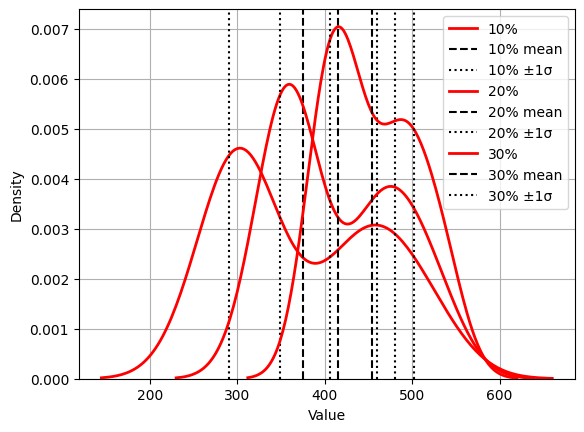

In [ ]:
# total_load_and_prices(combined_df['Time'], combined_df['Commercial_load']/1000, ev_com_load_unbalanced/1000, combined_df['Conv_prices'])
# peak_valley(combined_df['Time'], combined_df['Commercial_load']/1000, combined_df['Conv_prices'], combined_df['Com_action_p1'])
# peak_valley_balance(combined_df['Time'], combined_df['Commercial_load']/1000, combined_df['Conv_prices'], combined_df['Com_action_p1'], combined_df['Com_action_p2'])
# total_load_and_prices(combined_df['Time'], combined_df['Commercial_load']/1000, combined_df['Com_pv_ev_load']/1000, combined_df['Conv_prices']+combined_df['Com_action_p1'])
# total_load_and_prices(combined_df['Time'], combined_df['Commercial_load']/1000, combined_df['Com_pvb_ev_load']/1000, combined_df['Conv_prices']+0.5*(combined_df['Com_action_p1']+combined_df['Com_action_p2']))
# utilizations(combined_df['Time'], combined_df['Commercial_load']+ev_com_load_unbalanced, combined_df['Commercial_load']+combined_df['Com_pv_ev_load'], combined_df['Commercial_load']+combined_df['Com_pvb_ev_load'], com_max)
# penetration_levels(combined_df['Time'], combined_df['Commercial_load'], combined_df['Com_pvb_ev_load'])
# diff_peak_valley(combined_df['Commercial_load']+ev_com_load_unbalanced, combined_df['Commercial_load']+combined_df['Com_pv_ev_load'], combined_df['Commercial_load']+combined_df['Com_pvb_ev_load'])
# diff_peak_valley(combined_df['Commercial_load']+0.2*combined_df['Com_pvb_ev_load'], combined_df['Commercial_load']+0.6*combined_df['Com_pvb_ev_load'], combined_df['Commercial_load']+combined_df['Com_pvb_ev_load'])
# kde_comparisons(combined_df['Commercial_load']+0.2*combined_df['Com_pvb_ev_load'], combined_df['Commercial_load']+0.6*combined_df['Com_pvb_ev_load'], combined_df['Commercial_load']+combined_df['Com_pvb_ev_load'])

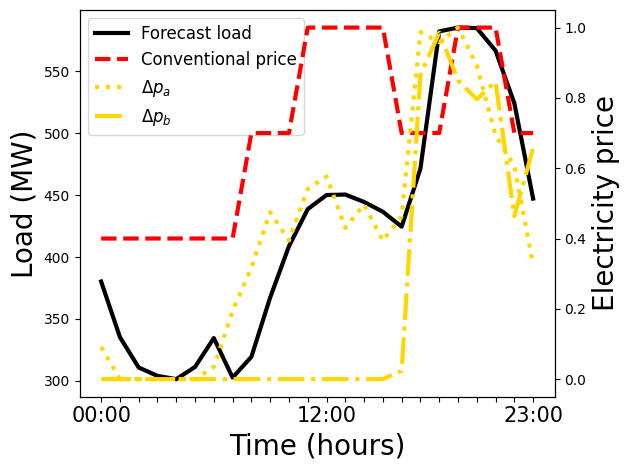

In [ ]:
# total_load_and_prices(combined_df['Time'], combined_df['Residential_load']/1000, ev_res_load_unbalanced/1000, combined_df['Conv_prices'])
# peak_valley(combined_df['Time'], combined_df['Residential_load']/1000, combined_df['Conv_prices'], combined_df['Res_action_p1'])
# peak_valley_balance(combined_df['Time'], combined_df['Residential_load']/1000, combined_df['Conv_prices'], combined_df['Res_action_p1'], combined_df['Res_action_p2'])
# total_load_and_prices(combined_df['Time'], combined_df['Residential_load']/1000, combined_df['Res_pv_ev_load']/1000, combined_df['Conv_prices']+combined_df['Res_action_p1'])
# total_load_and_prices(combined_df['Time'], combined_df['Residential_load']/1000, combined_df['Res_pvb_ev_load']/1000, combined_df['Conv_prices']+0.5*(combined_df['Res_action_p1']+combined_df['Res_action_p2']))
# utilizations(combined_df['Time'], combined_df['Residential_load']+ev_res_load_unbalanced, combined_df['Residential_load']+combined_df['Res_pv_ev_load'], combined_df['Residential_load']+combined_df['Res_pvb_ev_load'], res_max)
# diff_peak_valley(combined_df['Residential_load']+ev_res_load_unbalanced, combined_df['Residential_load']+combined_df['Res_pv_ev_load'], combined_df['Residential_load']+combined_df['Res_pvb_ev_load'])
# diff_peak_valley(combined_df['Residential_load']+0.2*combined_df['Res_pvb_ev_load'], combined_df['Residential_load']+0.6*combined_df['Res_pvb_ev_load'], combined_df['Residential_load']+combined_df['Res_pvb_ev_load'])
# kde_comparisons(combined_df['Residential_load']+0.2*combined_df['Res_pvb_ev_load'], combined_df['Residential_load']+0.6*combined_df['Res_pvb_ev_load'], combined_df['Residential_load']+combined_df['Res_pvb_ev_load'])


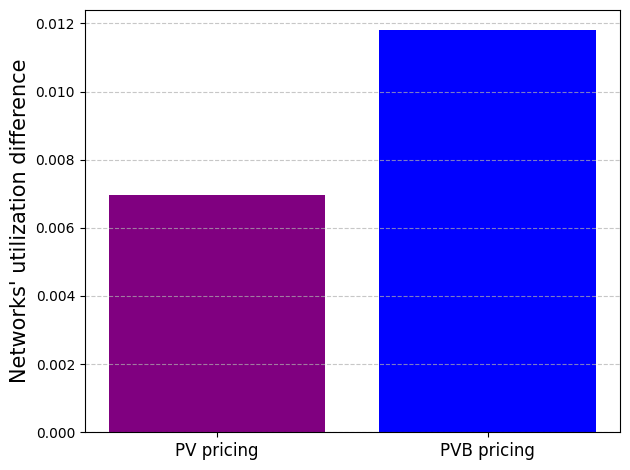

In [119]:
# utilizations(combined_df['Time'], combined_df['Residential_load']+ev_res_load_unbalanced, combined_df['Residential_load']+combined_df['Res_pv_ev_load'], combined_df['Residential_load']+combined_df['Res_pvb_ev_load'], res_max)
diff_utils(combined_df['Residential_load']+combined_df['Res_pv_ev_load'], combined_df['Commercial_load']+combined_df['Com_pv_ev_load'], combined_df['Residential_load']+combined_df['Res_pvb_ev_load'], combined_df['Commercial_load']+combined_df['Com_pvb_ev_load'], res_max, com_max)